In [5]:
import pandas as pd
import yfinance as yf
import psycopg2
from psycopg2.extras import execute_values
import time

# ==========================================
# 1. เชื่อมต่อ Database และสร้างตาราง
# ==========================================
print("🔄 กำลังเชื่อมต่อ Database...")
try:
    conn = psycopg2.connect(
        host="127.0.0.1", database="set_quant", user="postgres", password="Shifa.326459"
    )
    cur = conn.cursor()

    cur.execute("SELECT symbol FROM yfinance_stock_info WHERE market_cap > 0")
    symbols = [row[0] for row in cur.fetchall()]
    print(f"✅ พบหุ้นที่พร้อมดึงข้อมูลราคาย้อนหลังจำนวน {len(symbols)} ตัว")

    # ⭐️ จุดที่แก้ไข: สั่งลบตารางเก่าทิ้งก่อน (เพื่อล้างโครงสร้างเก่าที่ผิดพลาด)
    cur.execute("DROP TABLE IF EXISTS fact_daily_prices CASCADE;")
    
    # สร้างตาราง fact_daily_prices ใหม่เอี่ยม
    create_table_sql = """
    CREATE TABLE fact_daily_prices (
        symbol VARCHAR(20),
        date DATE,
        open FLOAT,
        high FLOAT,
        low FLOAT,
        close FLOAT,
        volume BIGINT,
        PRIMARY KEY (symbol, date)
    );
    """
    cur.execute(create_table_sql)
    conn.commit()
    print("✅ รีเซ็ตและสร้างตาราง 'fact_daily_prices' ใหม่สำเร็จ โครงสร้างถูกต้องเป๊ะ!")

    # ==========================================
    # 2. วนลูปดึงข้อมูลจาก yfinance และ Bulk Insert ลง Database
    # ==========================================
    print("\n⏳ เริ่มต้นดึงข้อมูลราคาย้อนหลัง 5 ปี (ใช้เวลาประมาณ 10-15 นาที)...")
    
    insert_sql = """
        INSERT INTO fact_daily_prices (symbol, date, open, high, low, close, volume)
        VALUES %s
        ON CONFLICT (symbol, date) DO NOTHING;
    """

    success_count = 0
    
    for sym in symbols:
        try:
            yf_symbol = f"{sym}.BK"
            
            ticker = yf.Ticker(yf_symbol)
            hist = ticker.history(period="5y")
            
            if hist.empty:
                continue
                
            records = []
            for index, row in hist.iterrows():
                # ดักจับค่า NaN ที่อาจทำให้ Database พัง
                if pd.isna(row['Close']): 
                    continue
                    
                records.append((
                    sym, 
                    index.date(), 
                    float(row['Open']), 
                    float(row['High']), 
                    float(row['Low']), 
                    float(row['Close']), 
                    int(row['Volume'])
                ))
            
            if records:
                execute_values(cur, insert_sql, records)
                conn.commit()
                success_count += 1
            
            time.sleep(0.5)

        except Exception as fetch_err:
            print(f"\n❌ ข้ามหุ้น {sym} เนื่องจาก Error: {fetch_err}")
            conn.rollback()
            continue
            
    print(f"\n🎉 ALL DONE! บันทึกข้อมูลราคาย้อนหลังสำเร็จ {success_count} / {len(symbols)} ตัว")

except Exception as e:
    print(f"❌ Database Error: {e}")
finally:
    if 'conn' in locals() and conn:
        cur.close()
        conn.close()
        print("🔒 ปิดการเชื่อมต่อ Database เรียบร้อย")

🔄 กำลังเชื่อมต่อ Database...
✅ พบหุ้นที่พร้อมดึงข้อมูลราคาย้อนหลังจำนวน 912 ตัว
✅ รีเซ็ตและสร้างตาราง 'fact_daily_prices' ใหม่สำเร็จ โครงสร้างถูกต้องเป๊ะ!

⏳ เริ่มต้นดึงข้อมูลราคาย้อนหลัง 5 ปี (ใช้เวลาประมาณ 10-15 นาที)...

🎉 ALL DONE! บันทึกข้อมูลราคาย้อนหลังสำเร็จ 912 / 912 ตัว
🔒 ปิดการเชื่อมต่อ Database เรียบร้อย


In [31]:
# ==========================================
# เช็คจำนวนหุ้นแยกตามตลาด (SET vs mai)
# ==========================================
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore') 
plt.rcParams['font.family'] = 'Tahoma' 
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

# 1. เชื่อมต่อฐานข้อมูล (รันครั้งเดียวใช้ได้ตลอดไฟล์)
conn = psycopg2.connect(host="127.0.0.1", database="set_quant", user="postgres", password="Shifa.326459")

display(Markdown("### 📌 ข้อมูลเพิ่มเติม: จำนวนหุ้นในตลาด SET และ mai"))

# คิวรี่นับจำนวนหุ้นจากตาราง set_companies_list
query_market_count = """
    SELECT market AS "Market (ตลาด)", COUNT(symbol) AS "Total Stocks (จำนวนหุ้น)"
    FROM set_companies_list
    WHERE market IN ('SET', 'mai')
    GROUP BY market
    ORDER BY "Total Stocks (จำนวนหุ้น)" DESC;
"""
df_market_count = pd.read_sql(query_market_count, conn)

display(df_market_count)

# คำนวณผลรวม
total_set = df_market_count.loc[df_market_count['Market (ตลาด)'] == 'SET', 'Total Stocks (จำนวนหุ้น)'].values[0]
total_mai = df_market_count.loc[df_market_count['Market (ตลาด)'] == 'mai', 'Total Stocks (จำนวนหุ้น)'].values[0]
print(f"👉 สรุป: มีหุ้นในตลาด SET จำนวน {total_set} ตัว และตลาด mai จำนวน {total_mai} ตัว")

### 📌 ข้อมูลเพิ่มเติม: จำนวนหุ้นในตลาด SET และ mai

,Market (ตลาด),Total Stocks (จำนวนหุ้น)
0,SET,696
1,mai,229


👉 สรุป: มีหุ้นในตลาด SET จำนวน 696 ตัว และตลาด mai จำนวน 229 ตัว


### 📌 5.13 - 5.20 Calculate and Plot SET, SET100, SET50, and MAI Indices

**ผลการคำนวณดัชนีจำลอง (Base 1000) 5 วันล่าสุด:**

,SET Index,SET100 Index,SET50 Index,MAI Index
date,,,,
2026-02-24,1287.062288,1463.700593,1689.279736,901.880387
2026-02-25,1309.590430,1492.371795,1724.430541,887.429075
2026-02-26,1325.743268,1512.941654,1749.127458,911.683218
2026-02-27,1326.860894,1514.664525,1751.502516,909.345983
2026-03-02,1272.105028,1456.958617,1687.920248,844.042122


#### 📊 แบบที่ 1: กราฟแยกทีละดัชนี (Individual Index Plots)

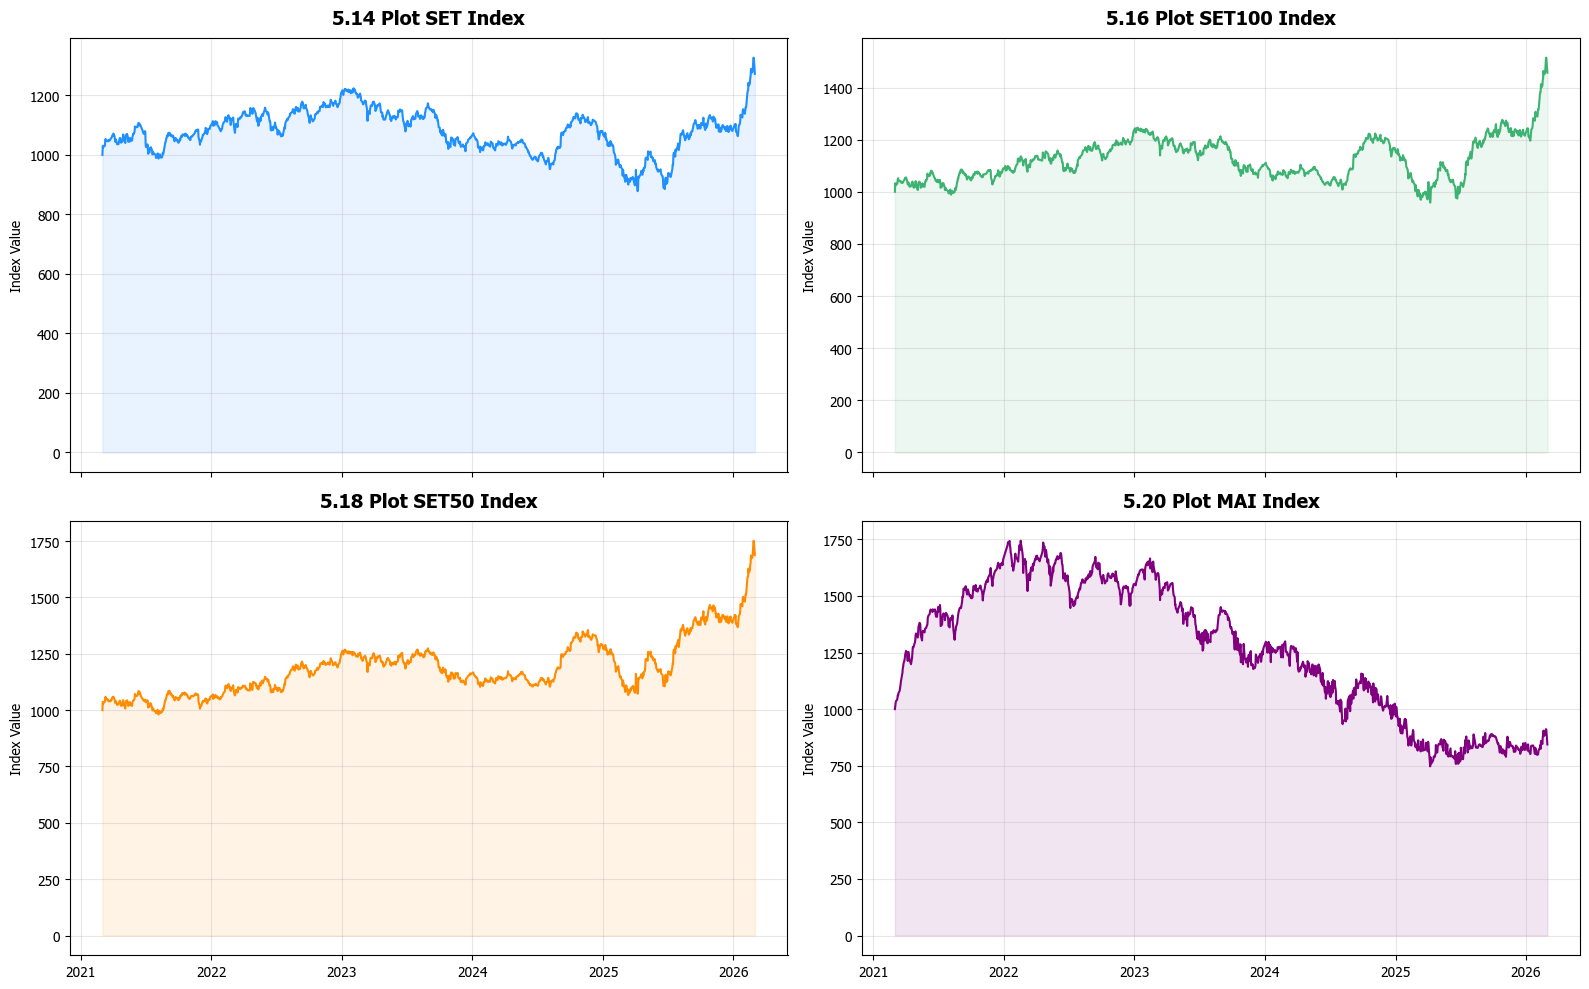

#### 📊 แบบที่ 2: กราฟรวมเปรียบเทียบทุกดัชนี (Combined Chart)

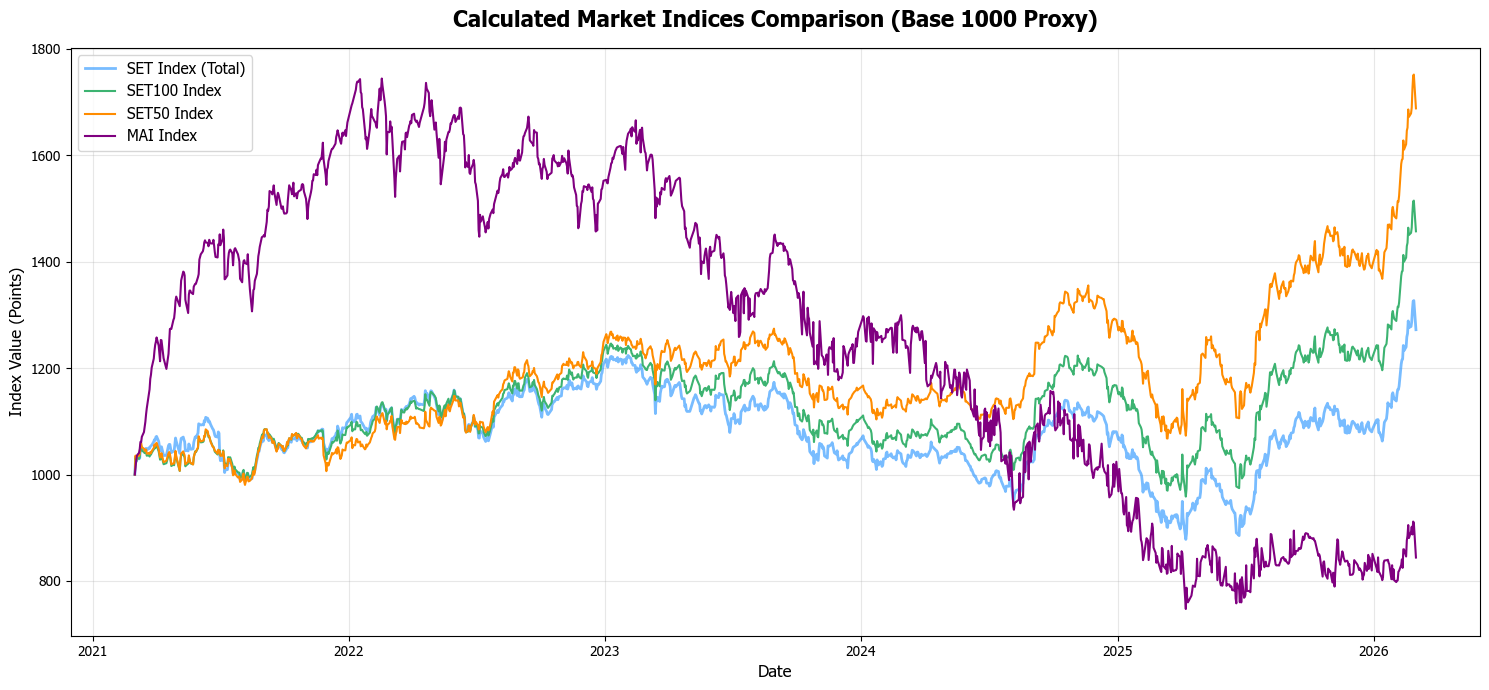

In [32]:
# ==========================================
# 5.13 - 5.20: Calculate and Plot ALL Market Indices (Separated & Combined)
# ==========================================
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from IPython.display import display, Markdown

# 1. ตั้งค่าพื้นฐาน
warnings.filterwarnings('ignore') 
plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.titlesize'] = 14

conn = psycopg2.connect(host="127.0.0.1", database="set_quant", user="postgres", password="Shifa.326459")

display(Markdown("### 📌 5.13 - 5.20 Calculate and Plot SET, SET100, SET50, and MAI Indices"))

# ---------------------------------------------------------
# ส่วนที่ 1: ใช้ฟังก์ชันดึงข้อมูลมาเก็บไว้ในตารางเดียว
# ---------------------------------------------------------
def calculate_proxy_index(market, limit=None):
    limit_clause = f"ORDER BY y.market_cap DESC LIMIT {limit}" if limit else ""
    query = f"""
    WITH index_stocks AS (
        SELECT s.symbol, (y.market_cap / NULLIF(y.current_price, 0)) AS shares_out
        FROM set_companies_list s
        JOIN yfinance_stock_info y ON s.symbol = y.symbol
        WHERE s.market = '{market}' AND y.market_cap > 0
        {limit_clause}
    ),
    daily_cap AS (
        SELECT p.date, SUM(p.close * i.shares_out) AS total_market_cap
        FROM fact_daily_prices p
        JOIN index_stocks i ON p.symbol = i.symbol
        GROUP BY p.date
    )
    SELECT 
        date, 
        (total_market_cap / FIRST_VALUE(total_market_cap) OVER (ORDER BY date)) * 1000 AS index_value
    FROM daily_cap ORDER BY date;
    """
    df = pd.read_sql(query, conn)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    return df['index_value']

# ดึงข้อมูลและสร้างเป็นตารางรวม
df_indices = pd.concat([
    calculate_proxy_index('SET'),
    calculate_proxy_index('SET', limit=100),
    calculate_proxy_index('SET', limit=50),
    calculate_proxy_index('mai')
], axis=1)
df_indices.columns = ['SET Index', 'SET100 Index', 'SET50 Index', 'MAI Index']

display(Markdown("**ผลการคำนวณดัชนีจำลอง (Base 1000) 5 วันล่าสุด:**"))
display(df_indices.tail())

# ---------------------------------------------------------
# ส่วนที่ 2: วาดกราฟแบบแยกทีละดัชนี
# ---------------------------------------------------------
display(Markdown("#### 📊 แบบที่ 1: กราฟแยกทีละดัชนี (Individual Index Plots)"))

# กำหนดสีและคำอธิบายสำหรับแต่ละดัชนี
plot_config = {
    'SET Index': {'color': 'dodgerblue', 'title': '5.14 Plot SET Index'},
    'SET100 Index': {'color': 'mediumseagreen', 'title': '5.16 Plot SET100 Index'},
    'SET50 Index': {'color': 'darkorange', 'title': '5.18 Plot SET50 Index'},
    'MAI Index': {'color': 'purple', 'title': '5.20 Plot MAI Index'}
}

# สร้าง Grid กราฟย่อยแบบ 2 แถว 2 คอลัมน์
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, col in enumerate(df_indices.columns):
    axes[i].plot(df_indices.index, df_indices[col], color=plot_config[col]['color'], linewidth=1.5)
    axes[i].set_title(plot_config[col]['title'], fontweight='bold', pad=10)
    axes[i].set_ylabel('Index Value')
    axes[i].grid(True, alpha=0.3)
    axes[i].fill_between(df_indices.index, df_indices[col], alpha=0.1, color=plot_config[col]['color'])

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# ส่วนที่ 3: วาดกราฟรวมทุกดัชนี
# ---------------------------------------------------------
display(Markdown("#### 📊 แบบที่ 2: กราฟรวมเปรียบเทียบทุกดัชนี (Combined Chart)"))

plt.figure(figsize=(15, 7))

# พล็อตเส้นกราฟทั้งหมดทับกัน
plt.plot(df_indices.index, df_indices['SET Index'], color='dodgerblue', label='SET Index (Total)', linewidth=2, alpha=0.6)
plt.plot(df_indices.index, df_indices['SET100 Index'], color='mediumseagreen', label='SET100 Index', linewidth=1.5)
plt.plot(df_indices.index, df_indices['SET50 Index'], color='darkorange', label='SET50 Index', linewidth=1.5)
plt.plot(df_indices.index, df_indices['MAI Index'], color='purple', label='MAI Index', linewidth=1.5)

plt.title('Calculated Market Indices Comparison (Base 1000 Proxy)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Index Value (Points)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### 📌 5.23 & 5.24 Calculate and Plot Indexing of EACH Stock Categories (Sorted by Performance)

**ผลการคำนวณดัชนี (เรียงจากกลุ่มที่ผลตอบแทนสูงสุด ➡️ ต่ำสุด):**

industry_group,เทคโนโลยี,ธุรกิจการเงิน,ทรัพยากร,อสังหาริมทรัพย์และก่อสร้าง,บริการ,สินค้าอุปโภคบริโภค,สินค้าอุตสาหกรรม,เกษตรและอุตสาหกรรมอาหาร
date,,,,,,,,
2026-02-24,4108.956082,1718.928198,1128.619687,959.863944,929.941417,676.480665,636.800587,548.781403
2026-02-25,4319.924937,1714.228167,1130.011023,973.385501,936.267148,681.725294,648.164001,552.630698
2026-02-26,4449.005488,1733.613848,1120.811783,971.298104,956.759956,682.780047,636.148889,557.279770
2026-02-27,4474.765654,1730.850604,1123.445940,974.598638,952.166788,682.001998,640.307230,550.427518
2026-03-02,4275.527069,1669.079207,1103.208363,925.492742,897.182215,626.066040,599.706948,531.491028


#### 📊 แบบที่ 1: กราฟแยกทีละกลุ่ม (เรียงอันดับซ้ายบน = ดีสุด)

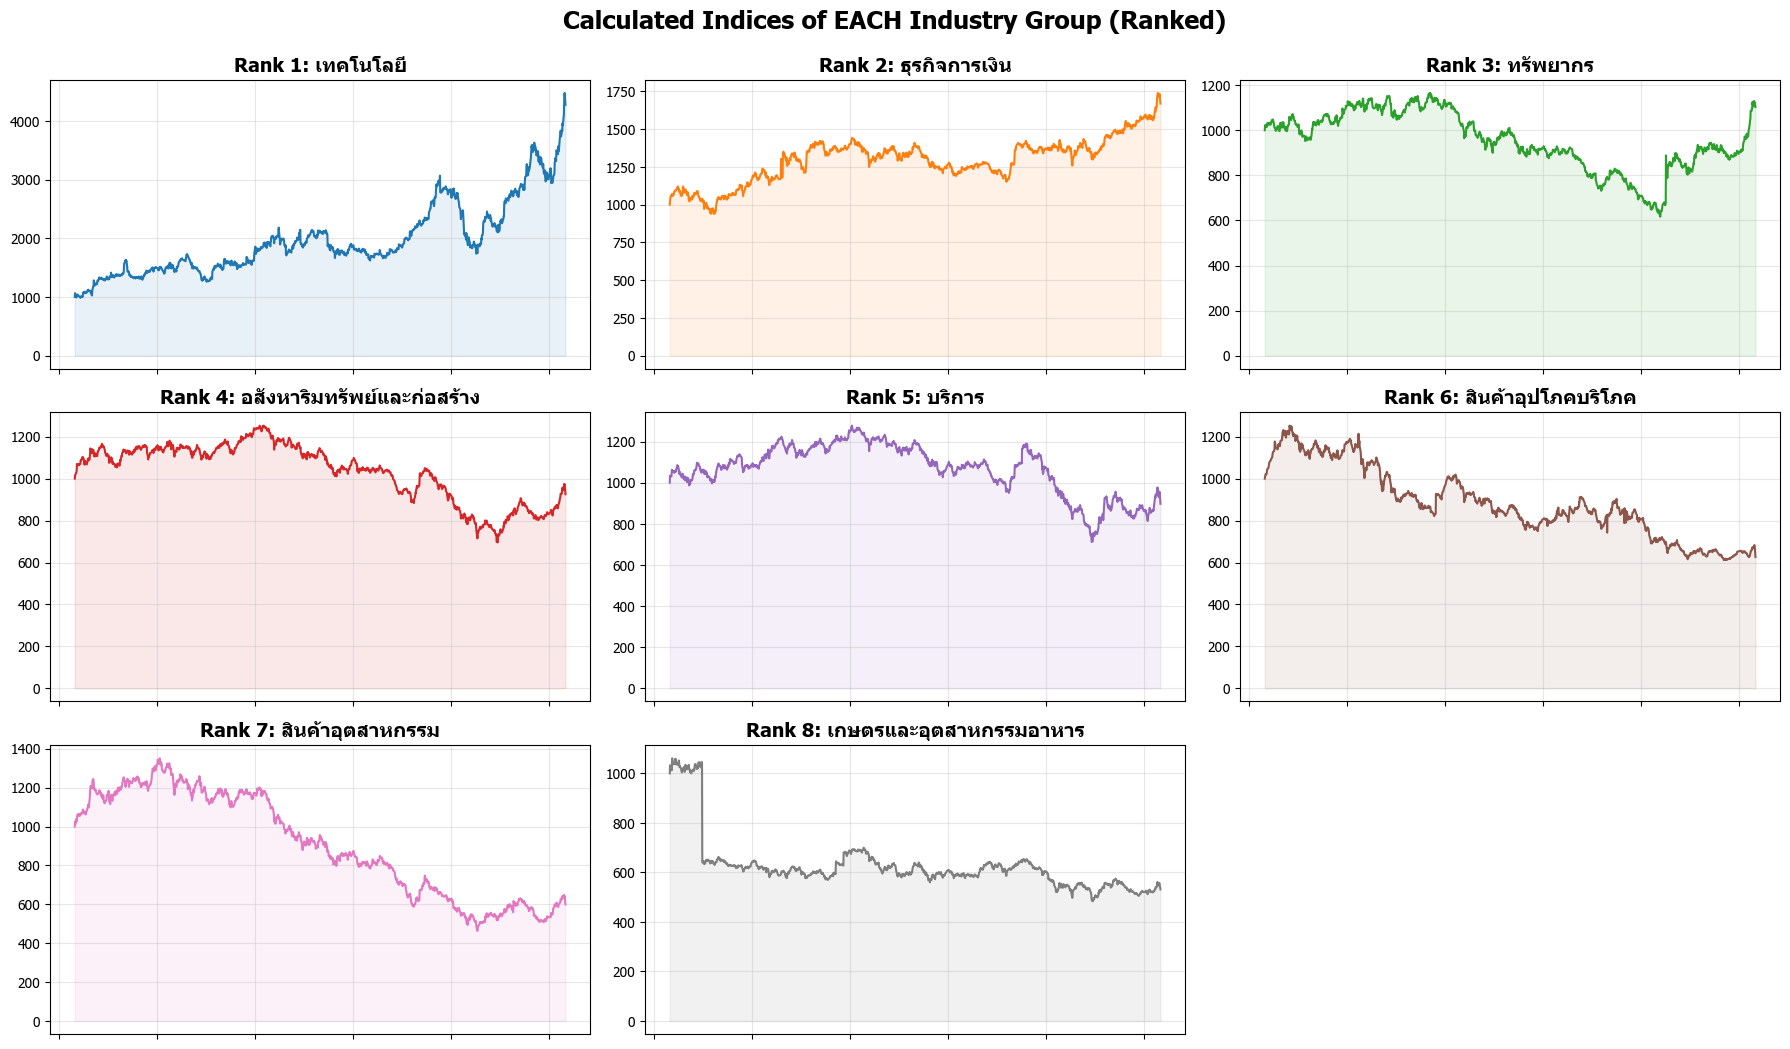

#### 📊 แบบที่ 2: กราฟรวมทุกกลุ่มอุตสาหกรรมเปรียบเทียบกัน

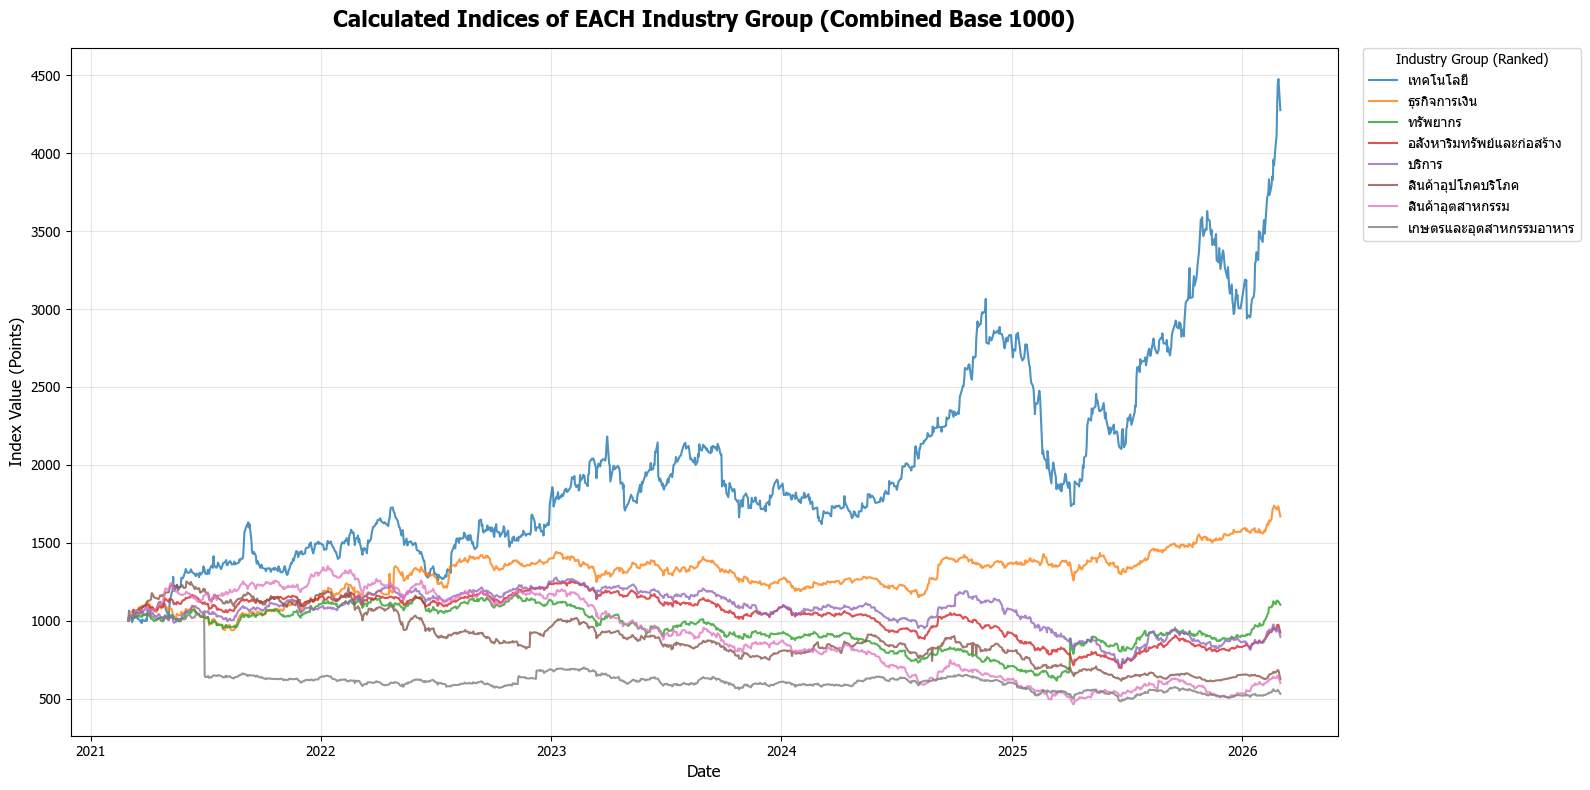

In [33]:

display(Markdown("### 📌 5.23 & 5.24 Calculate and Plot Indexing of EACH Stock Categories (Sorted by Performance)"))

# ---------------------------------------------------------
# ส่วนที่ 1: ดึงข้อมูลและคำนวณดัชนี
# ---------------------------------------------------------
query_all_sectors = """
WITH sector_stocks AS (
    SELECT s.symbol, s.industry_group, (y.market_cap / NULLIF(y.current_price, 0)) AS shares_out
    FROM set_companies_list s
    JOIN yfinance_stock_info y ON s.symbol = y.symbol
    WHERE s.industry_group IS NOT NULL 
      AND s.industry_group != 'N/A' 
      AND s.industry_group != '-'
      AND y.market_cap > 0
),
daily_sector_cap AS (
    SELECT p.date, ss.industry_group, SUM(p.close * ss.shares_out) AS total_market_cap
    FROM fact_daily_prices p
    JOIN sector_stocks ss ON p.symbol = ss.symbol
    GROUP BY p.date, ss.industry_group
)
SELECT 
    date, industry_group,
    (total_market_cap / FIRST_VALUE(total_market_cap) OVER (PARTITION BY industry_group ORDER BY date)) * 1000 AS proxy_sector_index
FROM daily_sector_cap
ORDER BY date, industry_group;
"""

df_all_sectors = pd.read_sql(query_all_sectors, conn)
df_all_sectors['date'] = pd.to_datetime(df_all_sectors['date'])
df_pivot = df_all_sectors.pivot(index='date', columns='industry_group', values='proxy_sector_index')

# ⭐️ จุดที่เพิ่มเข้ามา: เรียงลำดับคอลัมน์ (หมวดหมู่) ตามค่าดัชนีของ "วันล่าสุด" จากมากไปน้อย
# ใช้ .ffill() เผื่อมีบางหมวดไม่มีข้อมูลในวันสุดท้ายเป๊ะๆ จะได้ดึงข้อมูลวันก่อนหน้ามาใช้แทน
latest_values = df_pivot.ffill().iloc[-1].sort_values(ascending=False)
df_pivot = df_pivot[latest_values.index] # จัดเรียงตารางใหม่ตามอันดับแชมป์

display(Markdown("**ผลการคำนวณดัชนี (เรียงจากกลุ่มที่ผลตอบแทนสูงสุด ➡️ ต่ำสุด):**"))
display(df_pivot.tail())

# ---------------------------------------------------------
# ส่วนที่ 2: วาดกราฟแบบแยกทีละกลุ่ม เรียงตามอันดับ
# ---------------------------------------------------------
display(Markdown("#### 📊 แบบที่ 1: กราฟแยกทีละกลุ่ม (เรียงอันดับซ้ายบน = ดีสุด)"))

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 14), sharex=True)
axes = axes.flatten()

# ตอนนี้ df_pivot.columns ถูกเรียงจากอันดับ 1 ลงมาแล้ว วนลูป
for i, column in enumerate(df_pivot.columns):
    axes[i].plot(df_pivot.index, df_pivot[column], color=f'C{i}', linewidth=1.5)
    # ใส่ลำดับที่กำกับไว้ที่ชื่อกราฟด้วย จะได้รู้ว่าอยู่อันดับไหน
    axes[i].set_title(f"Rank {i+1}: {column}", fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].fill_between(df_pivot.index, df_pivot[column], alpha=0.1, color=f'C{i}')

for j in range(len(df_pivot.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Calculated Indices of EACH Industry Group (Ranked)', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.93) 
plt.show()

# ---------------------------------------------------------
# ส่วนที่ 3: วาดกราฟแบบรวมทุกเส้น (Combined Chart)
# ---------------------------------------------------------
display(Markdown("#### 📊 แบบที่ 2: กราฟรวมทุกกลุ่มอุตสาหกรรมเปรียบเทียบกัน"))

plt.figure(figsize=(16, 8))

for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], label=column, linewidth=1.5, alpha=0.8)

plt.title('Calculated Indices of EACH Industry Group (Combined Base 1000)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Index Value (Points)', fontsize=12)

# Legend ตอนนี้จะเรียงจากเส้นที่อยู่บนสุด ลงมาล่างสุด
plt.legend(title='Industry Group (Ranked)', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, borderaxespad=0.)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### 📌 5.25 & 5.26 Correlation between Stocks and SET Index

**✅ 5.26 Which stocks is move close to SET index most?**

👉 หุ้นที่เคลื่อนไหวใกล้เคียงกับ SET Index มากที่สุดคือ **STECON** โดยมีค่า Correlation สูงถึง **0.7200** (เข้าใกล้ 1.0 มากที่สุด)

,Stock Symbol,Correlation with SET
0,STECON,0.719958
1,MRDIYT,0.715048
2,BKIH,0.709720
3,TIDLOR,0.695856
4,POPF,0.690236
5,TRU,0.683929
6,SPALI,0.669865
7,CPN,0.659453
8,DUSIT,0.648405
9,RATCH,0.638876


#### 📊 5.25 Plot Correlation between Stocks with SET

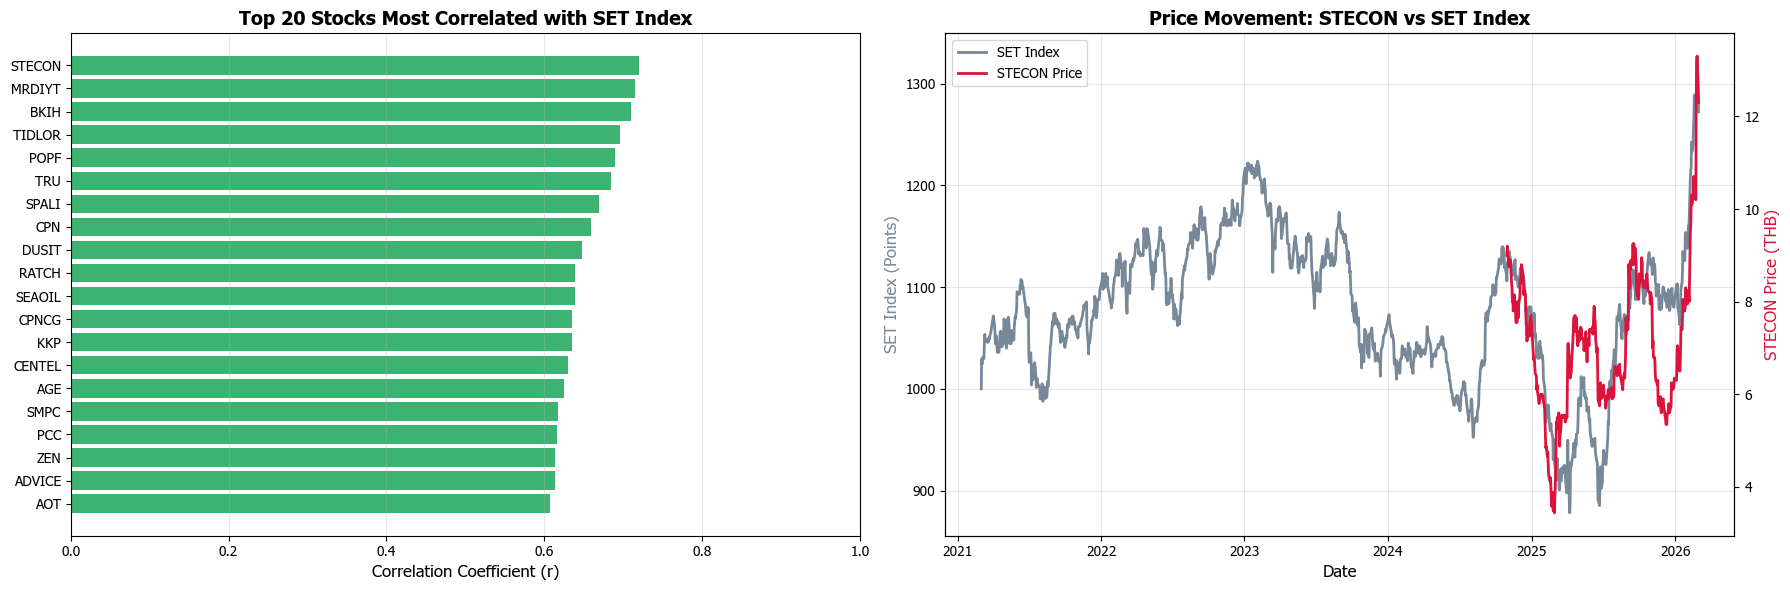

In [23]:
# 5.25 - 5.26: Plot Correlation and Find Stocks that Move Close to SET
display(Markdown("### 📌 5.25 & 5.26 Correlation between Stocks and SET Index"))

# ---------------------------------------------------------
# 1. ดึงข้อมูล SET Index และ ราคาปิดของหุ้นทุกตัว
# ---------------------------------------------------------
# (เราคำนวณ SET Index สดๆ อีกรอบเพื่อความชัวร์ว่าข้อมูลตรงกันเป๊ะ)
query_set_and_stocks = """
WITH set_stocks AS (
    SELECT s.symbol, (y.market_cap / NULLIF(y.current_price, 0)) AS shares_out
    FROM set_companies_list s
    JOIN yfinance_stock_info y ON s.symbol = y.symbol
    WHERE s.market = 'SET' AND y.market_cap > 0
),
daily_cap AS (
    SELECT p.date, SUM(p.close * ss.shares_out) AS total_market_cap
    FROM fact_daily_prices p
    JOIN set_stocks ss ON p.symbol = ss.symbol
    GROUP BY p.date
)
SELECT 
    date, 
    (total_market_cap / FIRST_VALUE(total_market_cap) OVER (ORDER BY date)) * 1000 AS set_index
FROM daily_cap ORDER BY date;
"""
df_set_corr = pd.read_sql(query_set_and_stocks, conn)
df_set_corr['date'] = pd.to_datetime(df_set_corr['date'])
df_set_corr.set_index('date', inplace=True)

# ดึงข้อมูลราคาปิด (Close Price) ของหุ้นทุกตัวในตลาด SET
query_all_stocks = """
    SELECT p.date, p.symbol, p.close
    FROM fact_daily_prices p
    JOIN set_companies_list s ON p.symbol = s.symbol
    WHERE s.market = 'SET'
"""
df_all_stocks = pd.read_sql(query_all_stocks, conn)
df_all_stocks['date'] = pd.to_datetime(df_all_stocks['date'])

# แปลงตารางให้อยู่ในรูปแบบ Pivot (วันที่อยู่แนวดิ่ง, ชื่อหุ้นอยู่แนวนอน)
df_pivot_stocks = df_all_stocks.pivot(index='date', columns='symbol', values='close')

# ---------------------------------------------------------
# 2. คำนวณความสัมพันธ์ (Correlation)
# ---------------------------------------------------------
# ใช้ .corrwith() เพื่อหาความสัมพันธ์ระหว่างหุ้นแต่ละตัว กับ SET Index
# ค่า Correlation จะอยู่ระหว่าง -1 ถึง 1 (เข้าใกล้ 1 แปลว่าวิ่งตามกันเป๊ะ)
stock_correlations = df_pivot_stocks.corrwith(df_set_corr['set_index']).dropna()

# เรียงลำดับจากมากไปน้อย
sorted_correlations = stock_correlations.sort_values(ascending=False)

# หาหุ้นที่วิ่งคล้ายตลาดมากที่สุด (อันดับ 1)
top_stock = sorted_correlations.index[0]
top_corr_value = sorted_correlations.iloc[0]

display(Markdown(f"**✅ 5.26 Which stocks is move close to SET index most?**"))
display(Markdown(f"👉 หุ้นที่เคลื่อนไหวใกล้เคียงกับ SET Index มากที่สุดคือ **{top_stock}** โดยมีค่า Correlation สูงถึง **{top_corr_value:.4f}** (เข้าใกล้ 1.0 มากที่สุด)"))

# โชว์ Top 10 ให้ดูเป็นตาราง
df_top10_corr = sorted_correlations.head(10).reset_index()
df_top10_corr.columns = ['Stock Symbol', 'Correlation with SET']
display(df_top10_corr)

# ---------------------------------------------------------
# 3. วาดกราฟ (5.25)
# ---------------------------------------------------------
display(Markdown("#### 📊 5.25 Plot Correlation between Stocks with SET"))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ---- กราฟที่ 1: Bar Chart แสดง Top 20 หุ้นที่วิ่งตามตลาด ----
top_20 = sorted_correlations.head(20)
axes[0].barh(top_20.index[::-1], top_20.values[::-1], color='mediumseagreen') # [::-1] เพื่อให้ตัวที่มากสุดอยู่บนสุด
axes[0].set_title('Top 20 Stocks Most Correlated with SET Index', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient (r)', fontsize=12)
axes[0].set_xlim(0, 1) # ค่าสูงสุดคือ 1
axes[0].grid(axis='x', alpha=0.3)

# ---- กราฟที่ 2: Line Chart เปรียบเทียบกราฟของหุ้นอันดับ 1 เทียบกับ SET Index ----
# ใช้แกน Y สองฝั่ง (Twin Axes) เพราะสเกลตัวเลขของ SET Index กับ ราคาหุ้นมันไม่เท่ากัน
ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(df_set_corr.index, df_set_corr['set_index'], color='lightslategray', linewidth=2, label='SET Index')
ax2.plot(df_pivot_stocks.index, df_pivot_stocks[top_stock], color='crimson', linewidth=2, label=f'{top_stock} Price')

ax1.set_title(f'Price Movement: {top_stock} vs SET Index', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('SET Index (Points)', color='lightslategray', fontsize=12)
ax2.set_ylabel(f'{top_stock} Price (THB)', color='crimson', fontsize=12)

# รวม Legend ไว้ด้วยกัน
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📌 5.27 & 5.28 Correlation between Stocks and Stocks

**✅ 5.28 Which stocks is close to stocks most?**

👉 คู่หุ้นที่เคลื่อนไหวคล้ายกันมากที่สุดราวกับฝาแฝดคือ **KPNREIT** และ **SUPER**

👉 โดยมีค่า Correlation สูงถึง **0.9899** (เข้าใกล้ 1.0 มากที่สุด)

#### 📊 5.27 Plot correlation between stocks and stocks (Heatmap)

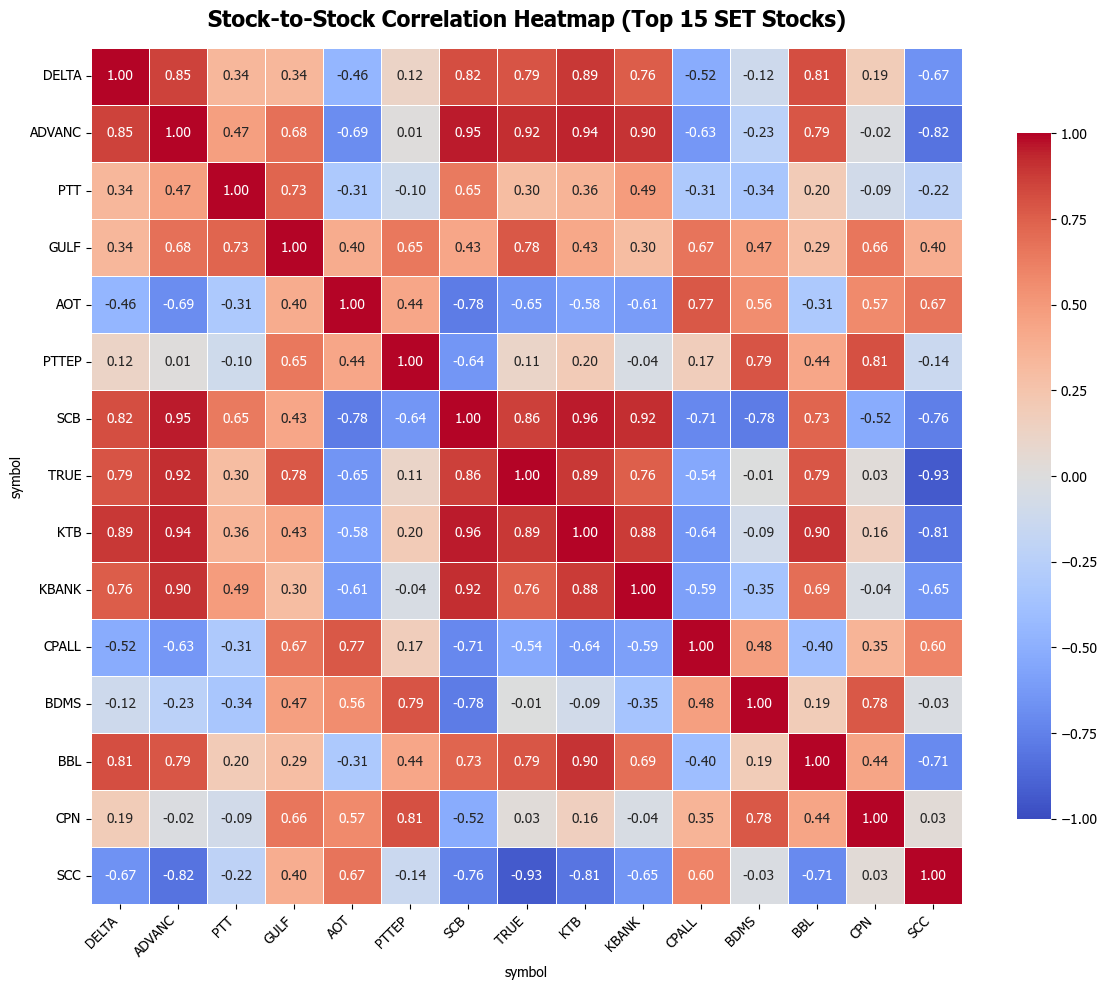

#### 📊 บทพิสูจน์หุ้นแฝด: KPNREIT vs SUPER

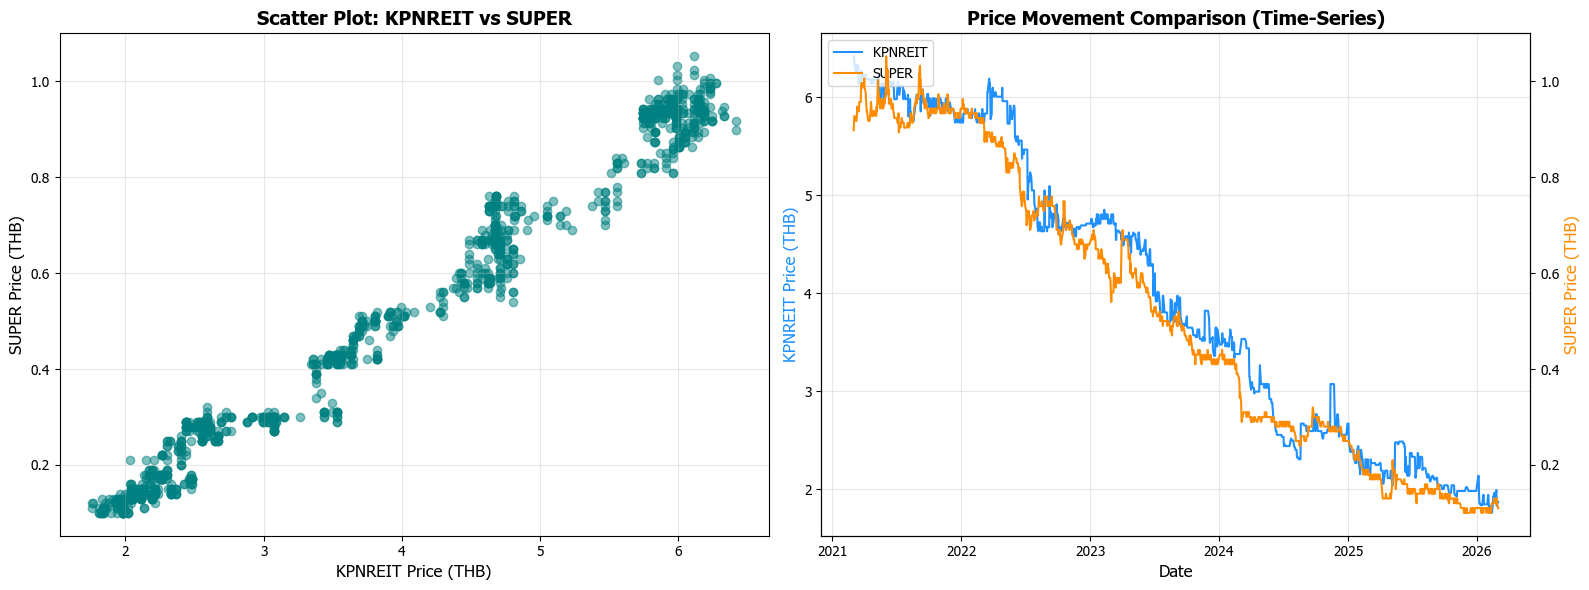

In [24]:
# ==========================================
# 5.27 - 5.28: Plot Stock-to-Stock Correlation & Find Closest Pair
# ==========================================
import seaborn as sns
import numpy as np

display(Markdown("### 📌 5.27 & 5.28 Correlation between Stocks and Stocks"))

# ---------------------------------------------------------
# 1. การคำนวณข้อ 5.28: หาคู่หุ้นที่คล้ายกันมากที่สุด (จากทั้งตลาด)
# ---------------------------------------------------------
# ใช้ df_pivot_stocks จากเซลล์ก่อนหน้า มาสร้าง Correlation Matrix ทั้งตลาด
corr_matrix_all = df_pivot_stocks.corr()

# ทริค: ลบค่า 1.0 แนวทแยงออก (เพราะหุ้นเทียบตัวเองจะได้ 1 เสมอ) และลบซีกซ้ายล่างออกเพื่อไม่ให้ข้อมูลซ้ำซ้อน
mask_all = np.tril(np.ones(corr_matrix_all.shape), k=0).astype(bool)
upper_tri_all = corr_matrix_all.where(~mask_all)

# หาค่า Correlation ที่สูงที่สุด และชื่อคู่หุ้นนั้น
max_corr_value = upper_tri_all.max().max()
stock_a, stock_b = upper_tri_all.stack().idxmax()

display(Markdown(f"**✅ 5.28 Which stocks is close to stocks most?**"))
display(Markdown(f"👉 คู่หุ้นที่เคลื่อนไหวคล้ายกันมากที่สุดราวกับฝาแฝดคือ **{stock_a}** และ **{stock_b}**"))
display(Markdown(f"👉 โดยมีค่า Correlation สูงถึง **{max_corr_value:.4f}** (เข้าใกล้ 1.0 มากที่สุด)"))

# ---------------------------------------------------------
# 2. การวาดกราฟข้อ 5.27: Heatmap ของหุ้นขนาดใหญ่ (Top 15)
# ---------------------------------------------------------
display(Markdown("#### 📊 5.27 Plot correlation between stocks and stocks (Heatmap)"))

# ดึงชื่อหุ้น Top 15 ตัวแรกตาม Market Cap มาเพื่อทำ Heatmap ให้ดูง่าย
query_top15 = """
    SELECT symbol 
    FROM yfinance_stock_info 
    WHERE market_cap > 0 
    ORDER BY market_cap DESC 
    LIMIT 15
"""
top15_symbols = pd.read_sql(query_top15, conn)['symbol'].tolist()

# กรองเอาเฉพาะข้อมูลราคาของ Top 15 แล้วหาความสัมพันธ์
df_top15 = df_pivot_stocks[top15_symbols]
corr_top15 = df_top15.corr()

plt.figure(figsize=(12, 10))
# สร้าง Heatmap
sns.heatmap(corr_top15, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, 
            vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.title('Stock-to-Stock Correlation Heatmap (Top 15 SET Stocks)', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. พิสูจน์ความฝาแฝดของคู่ชนะ (Scatter & Line Plot)
# ---------------------------------------------------------
display(Markdown(f"#### 📊 บทพิสูจน์หุ้นแฝด: {stock_a} vs {stock_b}"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- กราฟที่ 1: Scatter Plot (ดูการกระจายตัวเกาะเป็นเส้นตรง) ----
axes[0].scatter(df_pivot_stocks[stock_a], df_pivot_stocks[stock_b], alpha=0.5, color='teal')
axes[0].set_title(f'Scatter Plot: {stock_a} vs {stock_b}', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'{stock_a} Price (THB)', fontsize=12)
axes[0].set_ylabel(f'{stock_b} Price (THB)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# ---- กราฟที่ 2: Line Plot เปรียบเทียบการขึ้นลงรายวัน ----
# ใช้ 2 แกน Y กรณีที่ราคาของสองตัวนี้ต่างกันมาก (เช่น ตัวนึง 10 บาท ตัวนึง 100 บาท)
ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(df_pivot_stocks.index, df_pivot_stocks[stock_a], color='dodgerblue', linewidth=1.5, label=f'{stock_a}')
ax2.plot(df_pivot_stocks.index, df_pivot_stocks[stock_b], color='darkorange', linewidth=1.5, label=f'{stock_b}')

ax1.set_title(f'Price Movement Comparison (Time-Series)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel(f'{stock_a} Price (THB)', color='dodgerblue', fontsize=12)
ax2.set_ylabel(f'{stock_b} Price (THB)', color='darkorange', fontsize=12)

# รวม Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# ==========================================
# โบนัสพิเศษ: สแกนหา Top 15 คู่หุ้นที่คล้ายกันที่สุดในตลาด (แก้ไข Error แล้ว)
# ==========================================
from IPython.display import display, Markdown

display(Markdown("### 📌 ข้อมูลเชิงลึก: Top 15 คู่หุ้นที่เป็นฝาแฝดกันมากที่สุด (Highest Correlations)"))

# ⭐️ จุดที่แก้ไข: ใช้ rename_axis เพื่อเปลี่ยนชื่อแกนไม่ให้ซ้ำกันก่อนทำ reset_index
corr_pairs = upper_tri_all.rename_axis(index='Stock A', columns='Stock B').stack().reset_index()
corr_pairs.columns = ['Stock A', 'Stock B', 'Correlation']

# เรียงลำดับจากค่า Correlation สูงสุด (มากไปน้อย) และดึงมา 15 อันดับแรก
top_15_pairs = corr_pairs.sort_values(by='Correlation', ascending=False).head(15)

# รีเซ็ตตัวเลข Index ใหม่ให้เริ่มที่ 1 เพื่อความสวยงาม
top_15_pairs = top_15_pairs.reset_index(drop=True)
top_15_pairs.index = top_15_pairs.index + 1
top_15_pairs.index.name = 'Rank'

# แสดงผลตาราง
display(top_15_pairs)

### 📌 ข้อมูลเชิงลึก: Top 15 คู่หุ้นที่เป็นฝาแฝดกันมากที่สุด (Highest Correlations)

,Stock A,Stock B,Correlation
Rank,,,
1,KPNREIT,SUPER,0.989946
2,MICRO,RT,0.989338
3,AJ,SUPER,0.988116
4,RT,TAE,0.988083
5,AMR,CV,0.987817
6,AJ,AMR,0.987205
7,AJ,TAE,0.987134
8,AMR,UBE,0.987026
9,UBE,WFX,0.986996
